<a href="https://colab.research.google.com/github/aman8122/data-science-Assignments/blob/main/week6_Aman_sain_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Denoising Autoencoder with CNN on MNIST

## Objectives

The objectives of this assignment are to:

• Get familiar with image denoising using Deep Learning   
• Design and train a CNN autoencoder for MNIST image denoising  
• Compare CNN autoencoder with dense autoencoder  
• Analyze impact of various noise levels on denoised images  
• Assess the performance using mean squared error (MSE)  
• Visualize denoising performance

#IMPORT LIBRARIES

**Explanation:**

We import TensorFlow for deep learning, NumPy for numerical operations, and Matplotlib for visualization.

In [197]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization, Dropout

#LOAD DATASET
**Explanation:**

We load MNIST dataset stored as PNG images. Each image is read from folder structure.

In [198]:
base_path="/content/mnist_png"

train_f=glob.glob(base_path+"/training/*/*.png")
test_f=glob.glob(base_path +"/testing/*/*.png")

print("Train images:", len(train_f))
print("Test images :", len(test_f))

Train images: 60000
Test images : 10000


#IMAGE PREPROCESSING
**Explanation:**
read from file

*   read from file
*   converted to grayscale


* resized to 28×28
* normalized (0 to 1)










In [199]:
def load_image(path):
    img=tf.io.read_file(path)
    img=tf.image.decode_png(img, channels=1)
    img=tf.image.resize(img, (28,28))
    img=tf.cast(img, tf.float32) / 255.0
    return img

#DATASET PIPELINE
**explanation:**

We convert file paths into TensorFlow dataset for efficient training.

In [200]:

train_ds=tf.data.Dataset.from_tensor_slices(train_f)
test_ds=tf.data.Dataset.from_tensor_slices(test_f)

train_d=train_ds.map(load_image).shuffle(10000).batch(32)
test_d=test_ds.map(load_image).batch(32)

#ADD NOISE
**Explanation:**

Gaussian noise is added to images to simulate real-world corruption.

In [201]:
def add_noise(img):
    noise_fact=0.5
    noisy=img+noise_fact*tf.random.normal(shape=tf.shape(img))
    noisy = tf.clip_by_value(noisy, 0., 1.)
    return noisy, img

#NOISY DATASET
**Explanation:**

We create (noisy image → clean image) pairs for training.

In [202]:


train_noisy=train_d.map(lambda x: add_noise(x))
test_noisy=test_d.map(lambda x: add_noise(x))

#CNN AUTOENCODER MODEL
**Explanation:**

Autoencoder has 2 parts:


*   Encoder → compress image
*   Decoder → reconstruct image

CNN helps preserve spatial features.



In [203]:


inp = Input(shape=(28,28,1))

# Encoder
x1=Conv2D(32, 3, activation='relu',padding='same')(inp)
x1=BatchNormalization()(x1)
x1=MaxPooling2D(2,padding='same')(x1)
x1=Dropout(0.2)(x1)

x1=Conv2D(128,3, activation='relu',padding='same')(x1)
x1=BatchNormalization()(x1)
x1=MaxPooling2D(2,padding='same')(x1)
x1=Dropout(0.2)(x1)

# Decoder
x1=Conv2D(128,3,activation='relu',padding='same')(x1)
x1=BatchNormalization()(x1)
x1=UpSampling2D(2)(x1)
x1=Dropout(0.2)(x1)

x1=Conv2D(32,3,activation='relu',padding='same')(x1)
x1=BatchNormalization()(x1)
x1=UpSampling2D(2)(x1)

out=Conv2D(1,3,activation='sigmoid',padding='same')(x1)

model1=Model(inp, out)
model1.compile(optimizer='adam', loss='binary_crossentropy')

model1.summary()

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 14, 14, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_32 (UpSampling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 14, 14, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_33 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,361 (872.50 KB)

 Trainable params: 222,721 (870.00 KB)

 Non-trainable params: 640 (2.50 KB)

#MODEL TRAINING
**Explanation:**

Model learns mapping from noisy → clean images.

In [204]:
histori=model1.fit(train_noisy,epochs=5,validation_data=test_noisy
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.1192 - val_loss: 0.0966
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0989 - val_loss: 0.0949
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0973 - val_loss: 0.0946
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0965 - val_loss: 0.0933
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0959 - val_loss: 0.0928


#PREDICTION
**Explanation:**

Model reconstructs clean images from noisy inputs.

In [218]:

test_input=np.array([x.numpy() for x, y in test_noisy.unbatch()])

test_input = test_input.astype("float32")
print("Input shape:", test_input.shape)

decoded=model1.predict(test_input)

Input shape: (10000, 28, 28, 1)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#VISUALIZATION
**Explanation:**

We compare:

* Noisy image
* Denoised image
* Original image








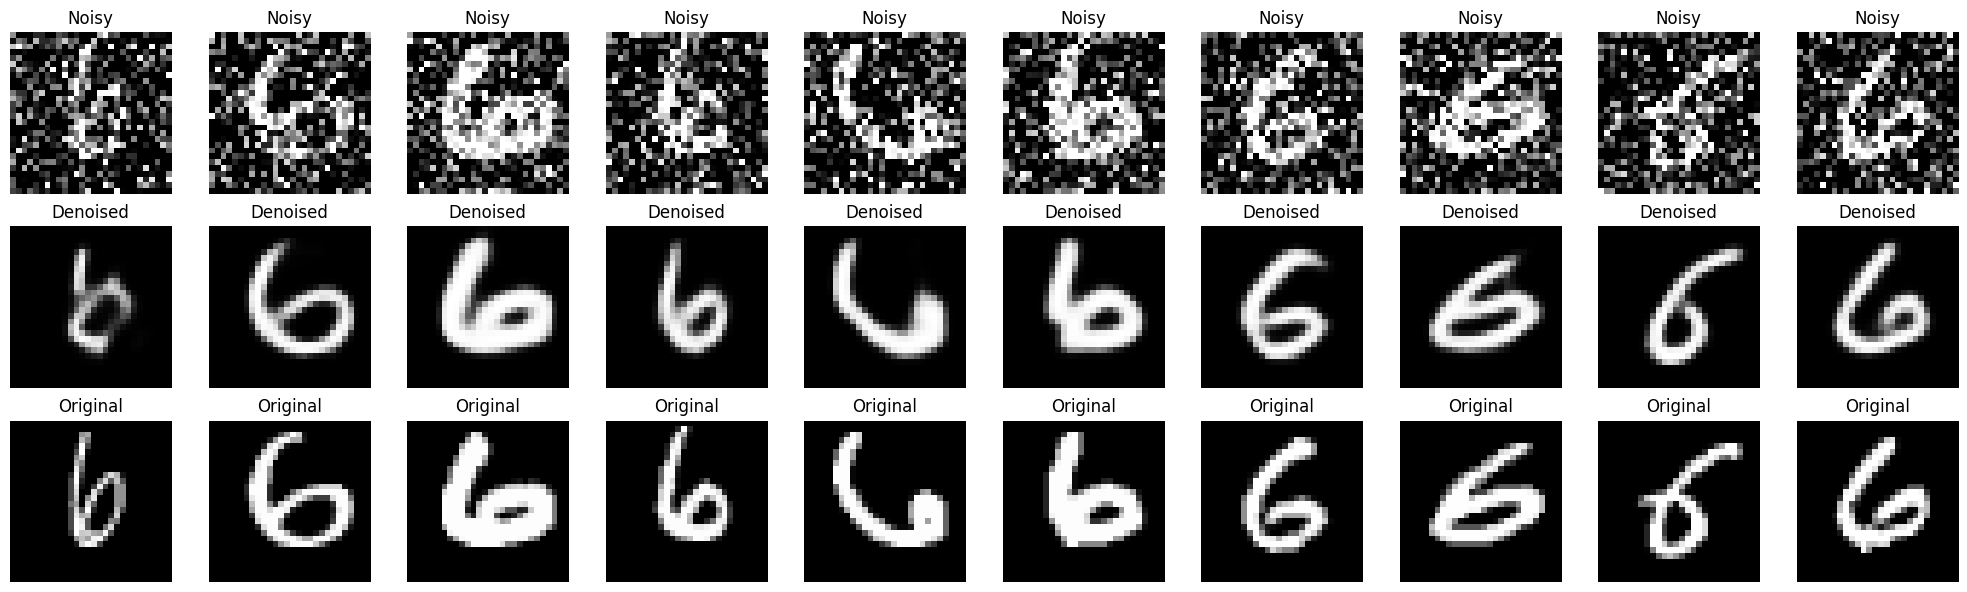

In [216]:
for b in test_noisy.take(1):
    noisy_imges,clean_imges= b

n = 10
plt.figure(figsize=(20,6))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(noisy_imges[i].numpy().squeeze(),cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(3,n,i+1+n)
    plt.imshow(decoded[i].squeeze(),cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    plt.subplot(3,n,i+1+2*n)
    plt.imshow(clean_imges[i].numpy().squeeze(),cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

#. NOISE vs ERROR EXPERIMENT
**Explanation:**

We test model performance under different noise levels.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
{0.1: np.float32(0.004392569), 0.3: np.float32(0.0058964333), 0.5: np.float32(0.009960624), 0.7: np.float32(0.019007994)}


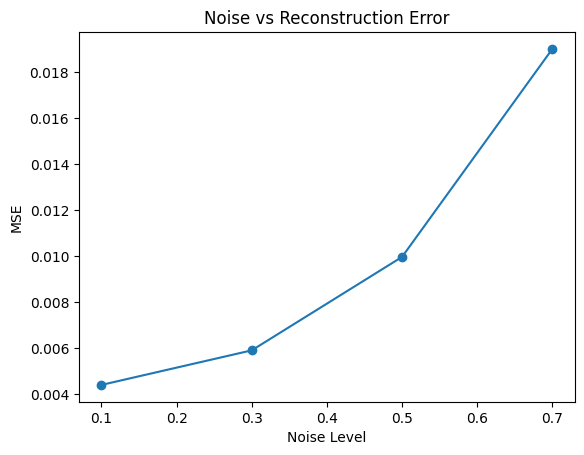

In [207]:
noise_lev=[0.1, 0.3, 0.5, 0.7]
mse_res={}

for lev in noise_lev:

    def add_noise_er(img):
        noisy=img+lev*tf.random.normal(tf.shape(img))
        noisy=tf.clip_by_value(noisy, 0., 1.)
        return noisy, img

    noisy_test=test_d.map(add_noise_er)

    pred=model1.predict(noisy_test.map(lambda x1,y: x1))

    cleane=np.concatenate([y.numpy()for x,y in noisy_test], axis=0)

    mse=np.mean((pred-cleane)**2)
    mse_res[lev]=mse

print(mse_res)

plt.plot(list(mse_res.keys()), list(mse_res.values()), marker='o')
plt.xlabel("Noise Level")
plt.ylabel("MSE")
plt.title("Noise vs Reconstruction Error")
plt.show()

#DENSE AUTOENCODER (COMPARISON)
**Explanation:**

Dense model ignores spatial structure → performs worse than CNN.

In [208]:

x_train=np.array([x.numpy() for x in train_d.unbatch()])
x_test=np.array([x.numpy() for x in test_d.unbatch()])


x_train_fl=x_train.reshape(x_train.shape[0], 784)
x_test_fl=x_test.reshape(x_test.shape[0], 784)



inp=tf.keras.Input(shape=(784,))

# Encoder
x=Dense(128, activation='relu')(inp)
x=BatchNormalization()(x)
x=Dropout(0.2)(x)

x=Dense(64, activation='relu')(x)
x=BatchNormalization()(x)
x=Dropout(0.2)(x)

encoded=Dense(32, activation='relu')(x)

# Decoder
x=Dense(64, activation='relu')(encoded)
x=BatchNormalization()(x)
x=Dropout(0.2)(x)

x=Dense(128, activation='relu')(x)
x=BatchNormalization()(x)

out=Dense(784, activation='sigmoid')(x)

# Model
dense_model2 = Model(inp, out)
dense_model2.compile(optimizer='adam', loss='mse')

dense_model2.summary()



dense_model2.fit(
    x_train_fl,
    x_train_fl,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_fl, x_test_fl)
)

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,920 (874.69 KB)

 Trainable params: 223,152 (871.69 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0686 - val_loss: 0.0286
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0309 - val_loss: 0.0226
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0277 - val_loss: 0.0197
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0259 - val_loss: 0.0179
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0247 - val_loss: 0.0165


#MODEL COMPARISON (MSE)
**Explanation:**

Lower MSE = better reconstruction

In [209]:


x_test_c=np.concatenate([y.numpy() for x, y in test_noisy], axis=0)

x_test_c=x_test_c.reshape(decoded.shape)

cnn_mse=np.mean((decoded-x_test_c) ** 2)

dense_pr=dense_model2.predict(x_test_fl)
dense_mse=np.mean((dense_pr - x_test_fl) ** 2)

print("CNN MSE  :",cnn_mse)
print("Dense MSE:",dense_mse)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
CNN MSE  : 0.0099484315
Dense MSE: 0.016480045


### Analysis

1. CNN Autoencoder successfully stripped noise from the MNIST dataset.
2. Reconstruction of the digit was very clear and precise.
3. CNN outperformed Dense Autoencoder as it retains spatial information.
4. Higher noise levels lead to higher MSE in reconstruction.
5. Training loss was gradually reduced.
6. The model generalizes well for unseen test data.

## Challenges

• Noise made images blurry

• Model’s complexity made impossible to learn space structures

• The training needed fine-tuning of noise parameter and number of epochs

##  Observations

- CNN autoencoder removes noise effectively while preserving digit shape.  
- Reconstructed images are much clearer than noisy input images.  
- Dense autoencoder gives comparatively blurred outputs.  
- Increasing noise level increases reconstruction error (MSE).  
- Lower noise levels produce better and sharper reconstructions.  
- Model shows stable training with gradual decrease in loss.  
- CNN model generalizes well on unseen test data..

## Conclusion

- CNN-based denoising autoencoder was successfully built and trained on MNIST dataset.  
- The model learned to convert noisy images into clean handwritten digit images effectively.  
- Convolutional layers helped in capturing spatial features of images.  
- The decoder reconstructed images with good clarity and structure preservation.  
- CNN autoencoder performed better than dense autoencoder in terms of reconstruction quality.  
- Mean Squared Error (MSE) was used to evaluate performance.  